# Analyse exploratoire — CropYield Prediction

**Objectif** : comprendre les quatre fichiers sources et repérer ce qui compliquera leur assemblage.

**Données** : `data/crop-yield-prediction/`

| Fichier | Une ligne | Colonnes utiles | Période | Pays |
|---|---|---|---|---|
| `pesticides.csv` | pays, année | `Area`, `Year`, `Value` (tonnes de matière active) | 1990-2016 | 168 |
| `rainfall.csv` | pays, année | `Area`, `Year`, `average_rain_fall_mm_per_year` | 1985-2017 | 217 |
| `temp.csv` | pays, année, relevé | `country`, `year`, `avg_temp` | 1743-2013 | 137 |
| `yield.csv` | pays, culture, année | `Area`, `Item`, `Year`, `Value` (hg/ha) | 1961-2016 | 212 |
| `yield_df.csv` | assemblage déjà fait des quatre | — | 1990-2013 | 101 |

# Imports


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from agritech import geo, profile, utils
from agritech.config import PATHS

# Lecture des fichiers

In [2]:
files_dir = PATHS.data_crop_yield_prediction
fichiers = ["pesticides.csv", "rainfall.csv", "temp.csv", "yield.csv", "yield_df.csv"]

manquants = [nom for nom in fichiers if not (files_dir / nom).is_file()]
print("fichiers manquants :", manquants or "aucun")

fichiers manquants : aucun


In [3]:
df_pesticides = pd.read_csv(files_dir / "pesticides.csv")
df_rainfall = pd.read_csv(files_dir / "rainfall.csv")
df_temp = pd.read_csv(files_dir / "temp.csv")
df_yield = pd.read_csv(files_dir / "yield.csv")
df_yield_df = pd.read_csv(files_dir / "yield_df.csv")

# rainfall.csv a une espace initiale dans l'en-tête de sa colonne pays
df_rainfall.columns = df_rainfall.columns.str.strip()

## pesticides.csv

Colonnes utiles : `Area` (pays), `Year` (1990-2016), `Value` (tonnes de matière active).

In [4]:
df_pesticides.head()

,Domain,Area,Year,Element,Item,Unit,Value
0,Pesticides Use,Albania,1990,Use,Pesticides (total),tonnes of active ingredients,121.0
1,Pesticides Use,Albania,1991,Use,Pesticides (total),tonnes of active ingredients,121.0
2,Pesticides Use,Albania,1992,Use,Pesticides (total),tonnes of active ingredients,121.0
3,Pesticides Use,Albania,1993,Use,Pesticides (total),tonnes of active ingredients,121.0
4,Pesticides Use,Albania,1994,Use,Pesticides (total),tonnes of active ingredients,201.0


In [5]:
p_pesticides = profile.profile_report(df_pesticides, PATHS.docs / "eda_pesticides_rapport.html")

Observations       : 4,349
Variables          : 7
Cellules manquantes: 0 (0.00%)
Lignes dupliquees  : 0 (0.00%)
Taille en memoire  : 0.2 Mo
Types              : {'Text': 5, 'Numeric': 2}

Alertes :
 - [Domain] has a constant value
 - [Element] has a constant value
 - [Item] has a constant value
 - [Unit] has a constant value


In [6]:
print("Pays : ", df_pesticides["Area"].nunique())
print(f"Années : {min(df_pesticides.Year)}-{max(df_pesticides.Year)} ({df_pesticides.Year.nunique()} distinctes)")
print(f"Valeurs : {min(df_pesticides.Value)} - {max(df_pesticides.Value)} (moyenne : {df_pesticides.Value.mean()})")
print("   -> Nombre à 0 : ",len(df_pesticides[df_pesticides.Value == 0]))
print("   -> Nombre < 0.1 : ",len(df_pesticides[(df_pesticides.Value < 0.1) & (df_pesticides.Value > 0)]))

Pays :  168
Années : 1990-2016 (27 distinctes)
Valeurs : 0.0 - 1807000.0 (moyenne : 20303.34146470453)
   -> Nombre à 0 :  2
   -> Nombre < 0.1 :  25


### Distributions

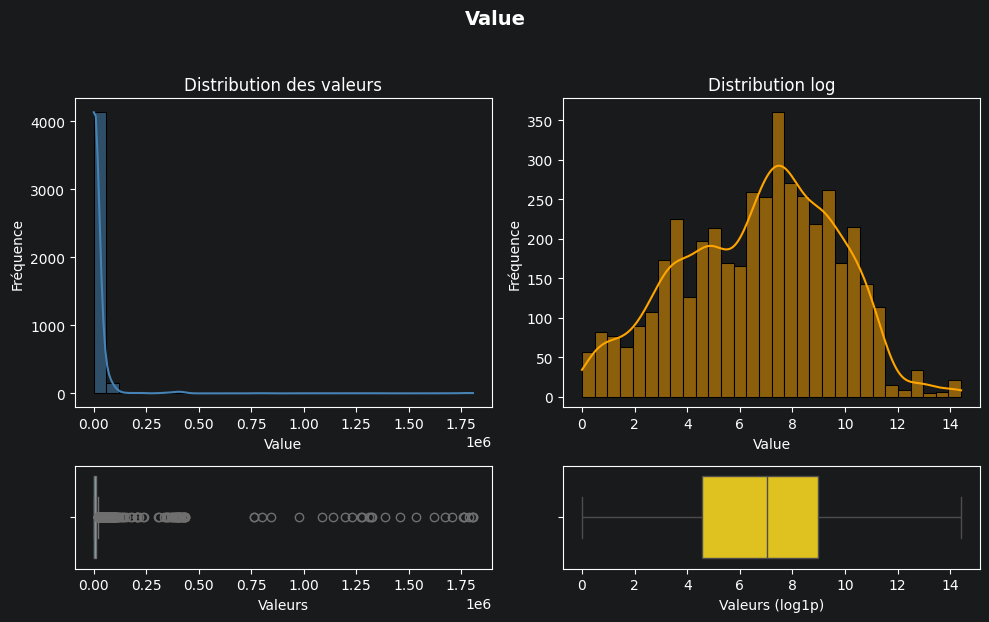

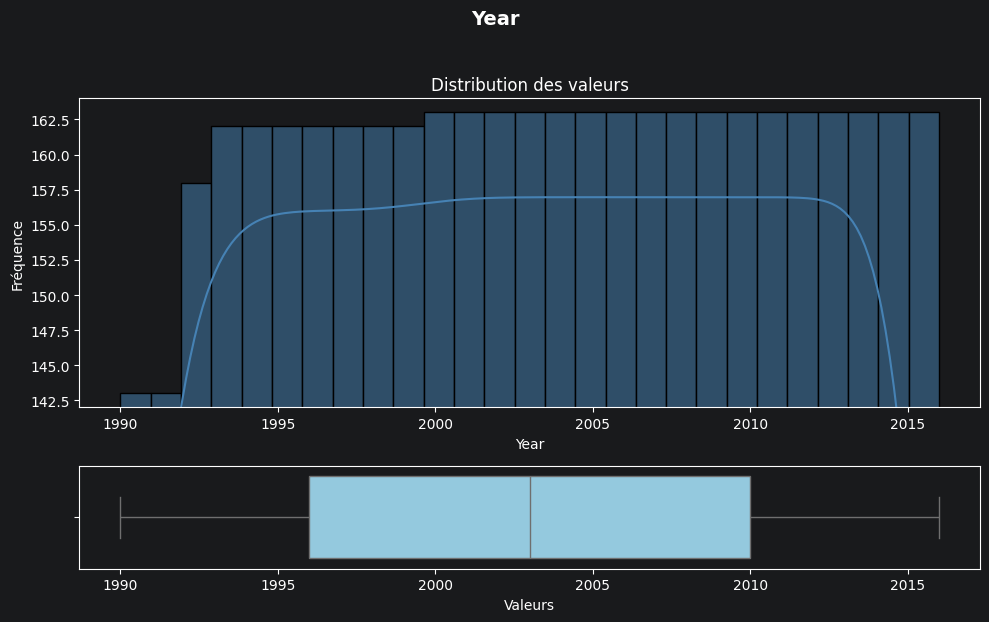

In [7]:
# une barre par année : sinon des intervalles tombent entre deux années entières
utils.plot_distrib(df_pesticides, "Value", do_log=True)
utils.plot_distrib(df_pesticides, "Year", bins=df_pesticides["Year"].nunique())

### Pays les plus consommateurs

In [8]:
df_country = (
    df_pesticides.groupby(["Area", "Year"], as_index=False)["Value"]
      .mean()
)

df_country_mean = (
    df_country.groupby("Area", as_index=False)["Value"]
              .mean()
              .sort_values("Value", ascending=False)
)

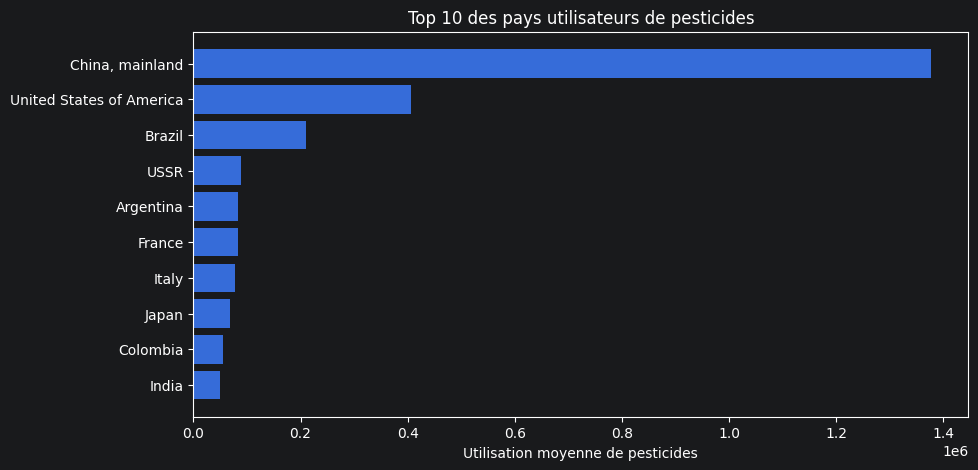

In [9]:
top10 = df_country_mean.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10["Area"], top10["Value"])
plt.xlabel("Utilisation moyenne de pesticides")
plt.title("Top 10 des pays utilisateurs de pesticides")
plt.gca().invert_yaxis()
plt.show()

In [10]:
df_country_stats = (
    df_pesticides
    .groupby("Area")["Value"]
    .agg(["mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

df_country_stats.head(10)

,mean,median,max
Area,,,
"China, mainland",1.377587e+06,1325226.00,1807000.00
United States of America,4.066033e+05,407779.20,434540.76
Brazil,2.100575e+05,182446.00,395646.00
USSR,8.920000e+04,89200.00,92200.00
Argentina,8.333572e+04,64568.95,207706.00
France,8.327432e+04,78577.00,114695.00
Italy,7.826321e+04,80454.00,100596.40
Japan,6.826507e+04,67869.72,79821.18
Colombia,5.486039e+04,52883.00,117881.45


**Observations :**

- Les tonnages varient énormément d'un pays à l'autre. `log1p(Value)` rend les petites valeurs plus lisibles tout en conservant les zéros.
- Ils dépendent surtout de la taille du pays et de ses surfaces agricoles : ce classement ne
  compare pas des pratiques.

### Utilisation moyenne de pesticides

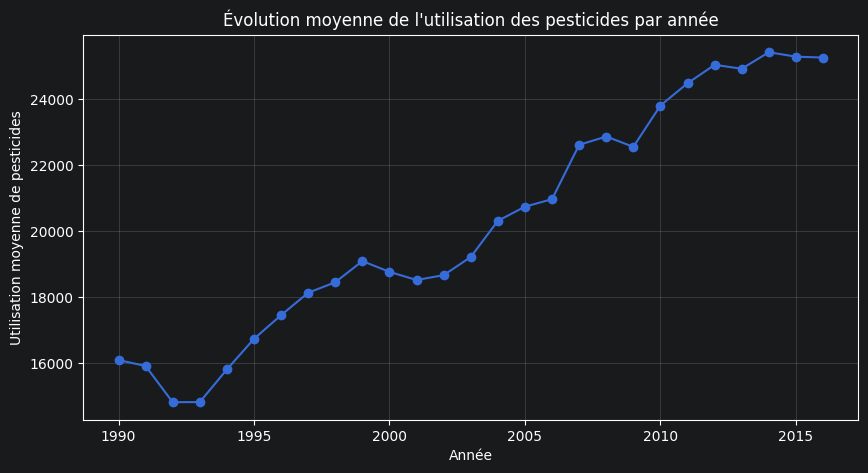

In [11]:
annual_mean = (
    df_pesticides
    .groupby("Year", as_index=False)["Value"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(annual_mean["Year"], annual_mean["Value"], marker="o")
plt.xlabel("Année")
plt.ylabel("Utilisation moyenne de pesticides")
plt.title("Évolution moyenne de l'utilisation des pesticides par année")
plt.grid(alpha=0.3)
plt.show()

## rainfall.csv

In [12]:
df_rainfall

,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327
...,...,...,...
6722,Zimbabwe,2013,657
6723,Zimbabwe,2014,657
6724,Zimbabwe,2015,657
6725,Zimbabwe,2016,657


In [13]:
p_rainfall = profile.profile_report(df_rainfall, PATHS.docs / "eda_rainfall_rapport.html")

Observations       : 6,727
Variables          : 3
Cellules manquantes: 774 (3.84%)
Lignes dupliquees  : 0 (0.00%)
Taille en memoire  : 0.2 Mo
Types              : {'Text': 2, 'Numeric': 1}

Alertes :
 - [average_rain_fall_mm_per_year] 774 (11.5%) missing values


In [14]:
df_rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6727 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Area                           6727 non-null   object
 1   Year                           6727 non-null   int64 
 2   average_rain_fall_mm_per_year  5953 non-null   object
dtypes: int64(1), object(2)
memory usage: 157.8+ KB


### Conversion de la colonne de pluie

La colonne est lue comme du texte : on regarde ce qui empêche sa conversion en nombre.

In [15]:
col_pluie = "average_rain_fall_mm_per_year"

converti = pd.to_numeric(df_rainfall[col_pluie], errors="coerce")
non_numeriques = converti.isna() & df_rainfall[col_pluie].notna()

print("NaN déjà lus par pandas  :", df_rainfall[col_pluie].isna().sum())
print("valeurs non convertibles :", df_rainfall.loc[non_numeriques, col_pluie].value_counts().to_dict())

df_rainfall[col_pluie] = converti

print(f"\nNaN après conversion     : {df_rainfall[col_pluie].isna().sum()} "
      f"({df_rainfall[col_pluie].isna().mean():.1%})")
print(f"min / max / moyenne      : {df_rainfall[col_pluie].min():.0f} / "
      f"{df_rainfall[col_pluie].max():.0f} / {df_rainfall[col_pluie].mean():.0f}")

NaN déjà lus par pandas  : 774
valeurs non convertibles : {'..': 6}

NaN après conversion     : 780 (11.6%)
min / max / moyenne      : 51 / 3240 / 1125


**Observations :**

- Seule la valeur `..`, sur 6 lignes, empêche la conversion.
- Après conversion : 780 valeurs manquantes (11,6 %), dont 774 étaient déjà vides.
- Pluie de 51 à 3 240 mm/an, moyenne 1 125 mm.

In [16]:
rainfall_missing = (
    df_rainfall
    .assign(
        missing=df_rainfall["average_rain_fall_mm_per_year"].isna()
    )
    .groupby("Year", as_index=False)["missing"]
    .sum()
)

annees = range(df_rainfall["Year"].min(), df_rainfall["Year"].max() + 1)
print("années absentes du fichier :", sorted(set(annees) - set(df_rainfall["Year"])))

rainfall_missing.sort_values("missing", ascending=False).head(10)

années absentes du fichier : [1988, 2003]


,Year,missing
0,1985,26
1,1986,26
3,1989,26
4,1990,26
5,1991,26
24,2011,25
20,2007,25
21,2008,25
22,2009,25
23,2010,25


In [17]:
rainfall_missing_country = (
    df_rainfall
    .assign(missing=df_rainfall[col_pluie].isna())
    .groupby("Area")["missing"]
    .agg(["sum", "count"])
)

rainfall_missing_country["missing_rate"] = (
    rainfall_missing_country["sum"] / rainfall_missing_country["count"]
)

rainfall_missing_country = rainfall_missing_country.sort_values("missing_rate", ascending=False)

print("pays avec au moins un manquant :", (rainfall_missing_country["sum"] > 0).sum(),
      "/", len(rainfall_missing_country))
print("pays entièrement manquants     :", (rainfall_missing_country["missing_rate"] == 1).sum())
partiels = rainfall_missing_country[rainfall_missing_country["missing_rate"].between(0, 1, inclusive="neither")]
print("pays partiellement manquants   :", partiels["missing_rate"].round(3).to_dict())
for pays_partiel in partiels.index:
    vides = df_rainfall.loc[(df_rainfall["Area"] == pays_partiel) & df_rainfall[col_pluie].isna(), "Year"].tolist()
    print(f"  {pays_partiel} : années sans valeur {vides}")
rainfall_missing_country.head(10)

pays avec au moins un manquant : 26 / 217
pays entièrement manquants     : 25
pays partiellement manquants   : {'Bahamas': 0.161}
  Bahamas : années sans valeur [1985, 1986, 1989, 1990, 1991]


,sum,count,missing_rate
Area,,,
New Caledonia,31,31,1.0
Turks and Caicos Islands,31,31,1.0
Tonga,31,31,1.0
British Virgin Islands,31,31,1.0
Isle of Man,31,31,1.0
Cayman Islands,31,31,1.0
Channel Islands,31,31,1.0
St. Martin (French part),31,31,1.0
"Hong Kong SAR, China",31,31,1.0


In [18]:
df_rainfall[df_rainfall["Area"] == "Bahamas"]

,Area,Year,average_rain_fall_mm_per_year
403,Bahamas,1985,NaN
404,Bahamas,1986,NaN
405,Bahamas,1987,1292.0
406,Bahamas,1989,NaN
407,Bahamas,1990,NaN
408,Bahamas,1991,NaN
409,Bahamas,1992,1292.0
410,Bahamas,1993,1292.0
411,Bahamas,1994,1292.0
412,Bahamas,1995,1292.0


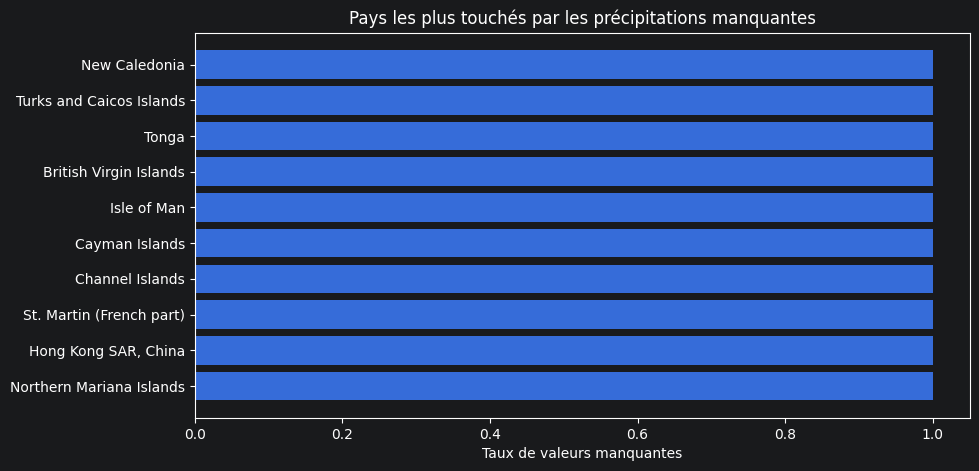

In [19]:
top_manquants = rainfall_missing_country.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_manquants.index, top_manquants["missing_rate"])
plt.xlabel("Taux de valeurs manquantes")
plt.title("Pays les plus touchés par les précipitations manquantes")
plt.gca().invert_yaxis()
plt.show()

**Observations :**

- 26 pays sur 217 ont des valeurs manquantes ; 25 d'entre eux, surtout des petits territoires,
  n'ont aucune valeur.
- Seul cas partiel : les Bahamas, sans valeur en 1985, 1986, 1989, 1990 et 1991.
- Les années 1988 et 2003 n'ont aucune ligne dans le fichier.

## temp.csv

In [20]:
df_temp

,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN
...,...,...,...
71306,2009,Mexico,21.76
71307,2010,Mexico,20.90
71308,2011,Mexico,21.55
71309,2012,Mexico,21.52


In [21]:
p_temp = profile.profile_report(df_temp, PATHS.docs / "eda_temp_rapport.html")

Observations       : 71,311
Variables          : 3
Cellules manquantes: 2547 (1.19%)
Lignes dupliquees  : 5005 (7.02%)
Taille en memoire  : 1.6 Mo
Types              : {'Numeric': 2, 'Text': 1}

Alertes :
 - Dataset has 5005 (7.0%) duplicate rows
 - [avg_temp] 2547 (3.6%) missing values


In [22]:
print("Pays : ", df_temp["country"].nunique())
print(f"Années : {min(df_temp.year)}-{max(df_temp.year)} ({df_temp.year.nunique()} distinctes)")
print(f"Valeurs : {min(df_temp.avg_temp)} - {max(df_temp.avg_temp)} (moyenne : {df_temp.avg_temp.mean()})")
print("   -> Nombre <= 0 : ",len(df_temp[df_temp.avg_temp <= 0]))
print("   -> Nombre  > 0 : ",len(df_temp[df_temp.avg_temp > 0]))

Pays :  137
Années : 1743-2013 (271 distinctes)
Valeurs : -14.35 - 30.73 (moyenne : 16.183876010703273)
   -> Nombre <= 0 :  505
   -> Nombre  > 0 :  68259


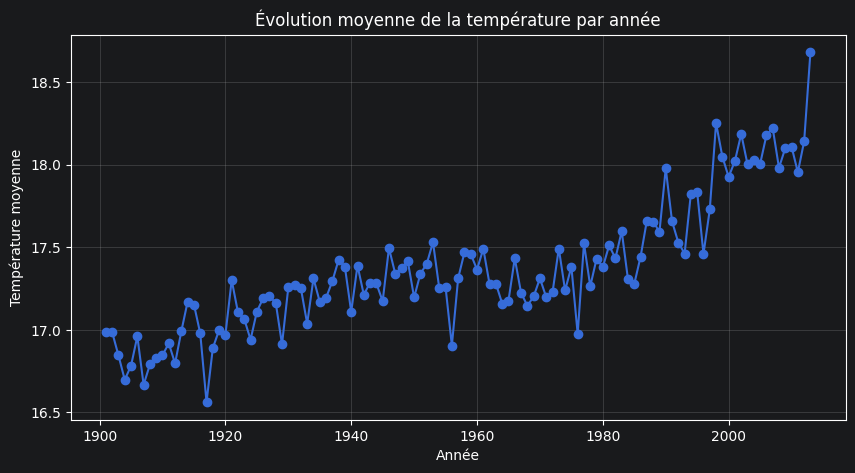

In [23]:
temp_annual_mean = (
    df_temp[df_temp["year"] > 1900]
    .groupby("year", as_index=False)["avg_temp"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(temp_annual_mean["year"], temp_annual_mean["avg_temp"], marker="o")
plt.xlabel("Année")
plt.ylabel("Température moyenne")
plt.title("Évolution moyenne de la température par année")
plt.grid(alpha=0.3)
plt.show()

In [24]:
df_country_temp = (
    df_temp
    .groupby("country")["avg_temp"]
    .agg(["mean", "median", "max"])
    .sort_values("mean", ascending=False)
)
df_country_temp.head(10)

,mean,median,max
country,,,
Niger,29.039801,29.070,30.42
Burkina Faso,28.049167,28.060,29.41
Sudan,27.372804,26.985,30.73
Thailand,27.154263,27.135,28.98
Somalia,27.150851,27.140,28.28
Guinea Bissau,27.053861,27.015,28.36
Mauritania,27.023851,26.910,28.70
Mali,26.969557,26.955,28.53
Qatar,26.766707,26.730,29.70


### Doublons

In [25]:
print("lignes                                        :", len(df_temp))
print("doublons exacts, lignes en trop               :", df_temp.duplicated().sum())
print("lignes distinctes apparaissant plusieurs fois :",
      df_temp[df_temp.duplicated(keep=False)].drop_duplicates().shape[0])
print("couples (country, year) non uniques           :", df_temp.duplicated(["country", "year"]).sum())
print("maximum de lignes pour un même couple         :", df_temp.groupby(["country", "year"]).size().max())

sans_doublons = df_temp.drop_duplicates()
print(f"\naprès drop_duplicates : {len(sans_doublons)} lignes")
print("  couples encore dupliqués :", sans_doublons.duplicated(["country", "year"]).sum())

pays_dupliques = df_temp[df_temp.duplicated(keep=False)].groupby("country").size().sort_values(ascending=False)
print(f"\npays concernés : {pays_dupliques.index.nunique()} / {df_temp['country'].nunique()}")
print(pays_dupliques.head(5).to_string())

lignes                                        : 71311
doublons exacts, lignes en trop               : 6958
lignes distinctes apparaissant plusieurs fois : 5005
couples (country, year) non uniques           : 42797
maximum de lignes pour un même couple         : 52

après drop_duplicates : 64353 lignes
  couples encore dupliqués : 35839

pays concernés : 30 / 137
country
United States    4498
India            1577
China            1367
Pakistan         1053
Brazil            778


**Observations :**

- 6 958 lignes sont des doublons exacts. Le profiling indique 5 005 : c'est le nombre de lignes
  différentes qui sont répétées.
- Ces doublons concernent 30 pays, surtout les États-Unis, l'Inde et la Chine ; ils peuvent être
  supprimés sans perte.
- Même sans doublons, un pays peut avoir plusieurs températures différentes pour une même année
  (jusqu'à 52). Il faudra en faire la moyenne avant la jointure, sinon les lignes de rendement
  seraient dupliquées.

### Valeurs manquantes de `avg_temp`

In [26]:
print(f"manquants : {df_temp['avg_temp'].isna().sum()} ({df_temp['avg_temp'].isna().mean():.1%})")

periodes = []
for debut, fin in [(1743, 1799), (1800, 1899), (1900, 1989), (1990, 2013)]:
    extrait = df_temp[(df_temp["year"] >= debut) & (df_temp["year"] <= fin)]
    periodes.append({
        "période": f"{debut}-{fin}",
        "lignes": len(extrait),
        "manquants": extrait["avg_temp"].isna().sum(),
        "taux (%)": round(100 * extrait["avg_temp"].isna().mean(), 1),
    })

pd.DataFrame(periodes)

manquants : 2547 (3.6%)


,période,lignes,manquants,taux (%)
0,1743-1799,5498,613,11.1
1,1800-1899,26483,1934,7.3
2,1900-1989,31050,0,0.0
3,1990-2013,8280,0,0.0


**Observations :**

- Les 2 547 valeurs manquantes (3,6 %) datent toutes d'avant 1900.
- Aucune valeur manquante après 1900, donc aucune sur la période utilisée.

## yield.csv

In [27]:
df_yield

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400
...,...,...,...,...,...,...,...,...,...,...,...,...
56712,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2012,2012,hg/ha,24420
56713,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2013,2013,hg/ha,22888
56714,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2014,2014,hg/ha,21357
56715,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2015,2015,hg/ha,19826


In [28]:
p_yield = profile.profile_report(df_yield, PATHS.docs / "eda_yield_rapport.html")

Observations       : 56,717
Variables          : 12
Cellules manquantes: 0 (0.00%)
Lignes dupliquees  : 0 (0.00%)
Taille en memoire  : 5.2 Mo
Types              : {'Text': 6, 'Numeric': 6}

Alertes :
 - [Domain Code] has a constant value
 - [Domain] has a constant value
 - [Element Code] has a constant value
 - [Element] has a constant value
 - [Unit] has a constant value
 - [Year] is highly overall correlated with [Year Code]
 - [Year Code] is highly overall correlated with [Year]


In [29]:
print("Pays : ", df_yield["Area"].nunique())
print(f"Années : {min(df_yield.Year)}-{max(df_yield.Year)} ({df_yield.Year.nunique()} distinctes)")
print(f"Rendement : {min(df_yield.Value)} - {max(df_yield.Value)} (moyenne : {df_yield.Value.mean()})")
print("   -> Nombre = 0 : ",len(df_yield[df_yield.Value == 0]))

Pays :  212
Années : 1961-2016 (56 distinctes)
Rendement : 0 - 1000000 (moyenne : 62094.66008427808)
   -> Nombre = 0 :  8


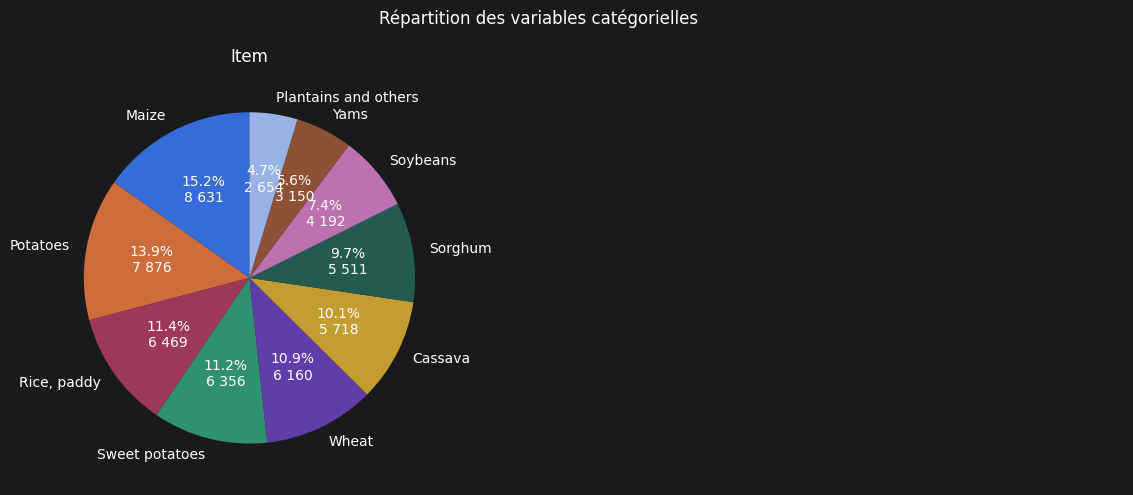

In [30]:
utils.plot_pies(df_yield, ["Item"])

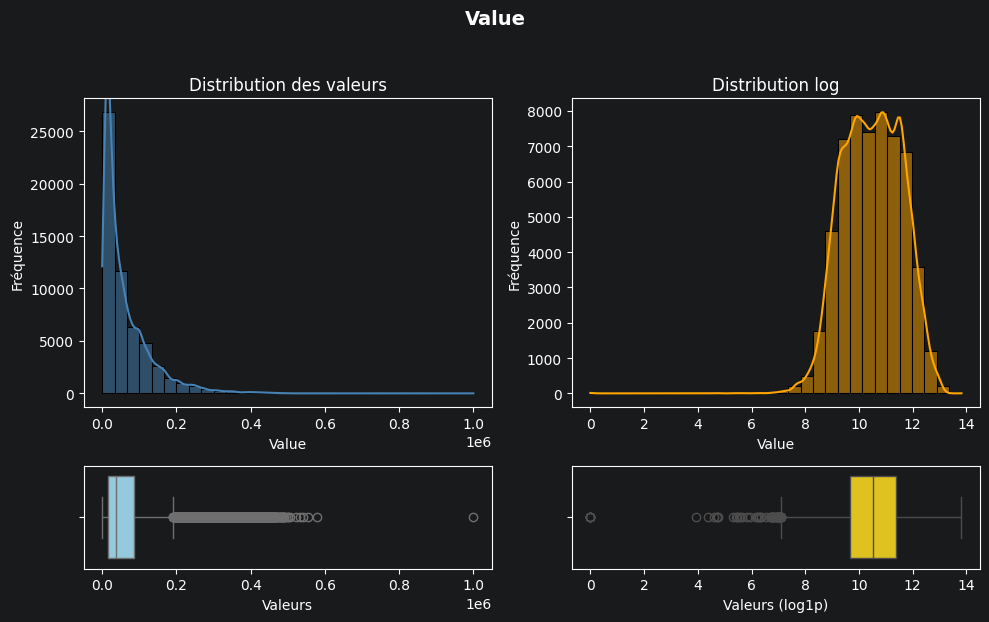

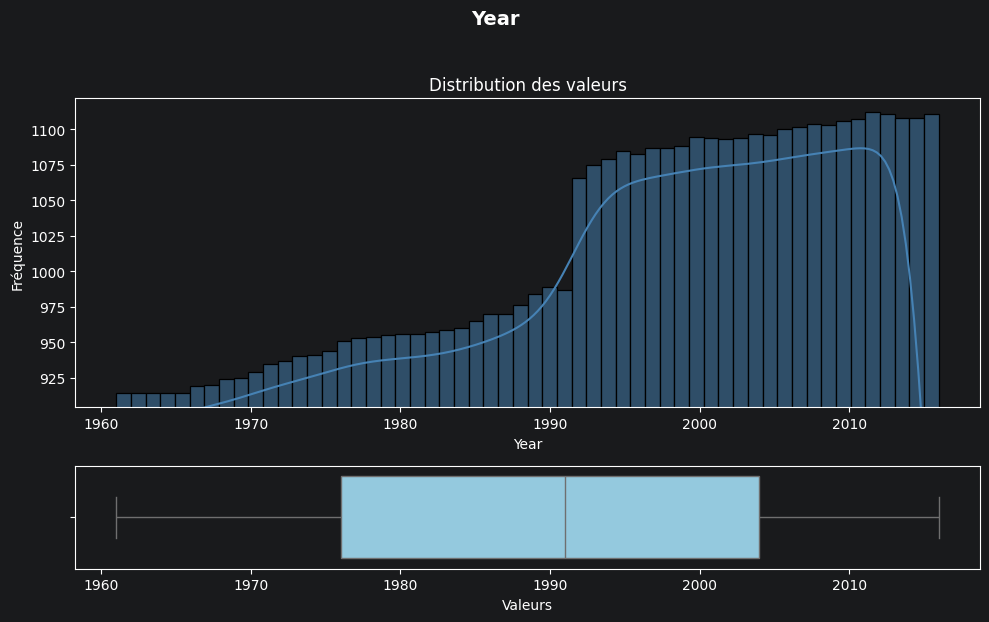

In [31]:
utils.plot_distrib(df_yield, "Value", do_log=True)
utils.plot_distrib(df_yield, "Year", bins=df_yield["Year"].nunique())

`log1p(Value)` atténue les grands rendements et facilite la lecture des valeurs faibles.

In [32]:
df_yield[["Item Code","Item"]].value_counts()

Item Code  Item                
56         Maize                   8631
116        Potatoes                7876
27         Rice, paddy             6469
122        Sweet potatoes          6356
15         Wheat                   6160
125        Cassava                 5718
83         Sorghum                 5511
236        Soybeans                4192
137        Yams                    3150
489        Plantains and others    2654
Name: count, dtype: int64

In [33]:
# Chaque code correspond-il à un seul nom ?
print("Area  :", df_yield.groupby("Area Code")["Area"].nunique().max(), "libellé par code")
print("Item  :", df_yield.groupby("Item Code")["Item"].nunique().max(), "libellé par code")

Area  : 1 libellé par code
Item  : 1 libellé par code


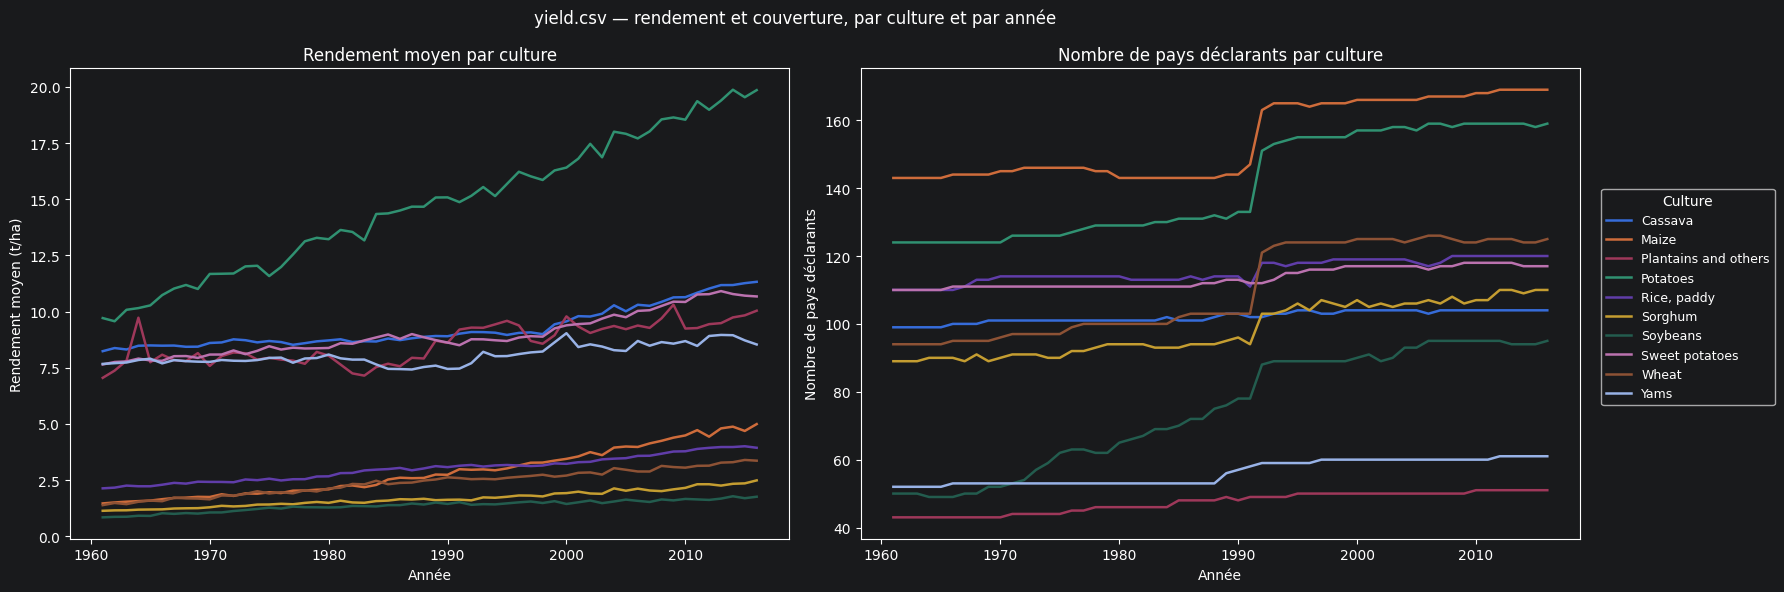

In [34]:
rendement = (
    df_yield.pivot_table(index="Year", columns="Item", values="Value", aggfunc="mean")
    .div(10_000)                                    # hg/ha -> t/ha
)
nb_pays = df_yield.pivot_table(index="Year", columns="Item", values="Area", aggfunc="nunique")
nb_pays = nb_pays[rendement.columns]                # même ordre -> mêmes couleurs des deux côtés

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rendement.plot(ax=axes[0], linewidth=1.8, legend=False)
axes[0].set_ylabel("Rendement moyen (t/ha)")
axes[0].set_xlabel("Année")
axes[0].set_title("Rendement moyen par culture")

nb_pays.plot(ax=axes[1], linewidth=1.8, legend=False)
axes[1].set_ylabel("Nombre de pays déclarants")
axes[1].set_xlabel("Année")
axes[1].set_title("Nombre de pays déclarants par culture")

# Une seule légende pour les deux graphiques
poignees, etiquettes = axes[0].get_legend_handles_labels()
fig.legend(poignees, etiquettes, title="Culture", loc="center left",
           bbox_to_anchor=(1.0, 0.5), fontsize=9)

fig.suptitle("yield.csv — rendement et couverture, par culture et par année")
fig.tight_layout()
plt.show()

**Observations :**

- Deux groupes de cultures : les tubercules (pomme de terre jusqu'à 19,9 t/ha en moyenne) et les
  céréales et légumineuses (soja au plus 1,8 t/ha).
- Ces écarts entre cultures n'existent pas dans le dataset parcellaire.
- Le nombre de pays qui déclarent change selon l'année, avec un saut en 1992 : une hausse du
  rendement moyen peut venir d'un changement de pays.

# Période commune aux sources

In [35]:
bornes = {
    "yield.csv": (df_yield["Year"].min(), df_yield["Year"].max()),
    "rainfall.csv": (df_rainfall["Year"].min(), df_rainfall["Year"].max()),
    "pesticides.csv": (df_pesticides["Year"].min(), df_pesticides["Year"].max()),
    "temp.csv": (df_temp["year"].min(), df_temp["year"].max()),
}

debut = max(a for a, _ in bornes.values())
fin = min(b for _, b in bornes.values())

for fichier, (a, b) in bornes.items():
    print(f"{fichier:16} {a} - {b}")
print(f"\npériode commune  {debut} - {fin}  ({fin - debut + 1} années)")
print(f"yield_df.csv     {df_yield_df['Year'].min()} - {df_yield_df['Year'].max()}")

yield.csv        1961 - 2016
rainfall.csv     1985 - 2017
pesticides.csv   1990 - 2016
temp.csv         1743 - 2013

période commune  1990 - 2013  (24 années)
yield_df.csv     1990 - 2013


**Observations :**

- Période commune : 1990-2013 (24 ans). `pesticides.csv` commence en 1990 et `temp.csv` s'arrête
  en 2013.
- C'est la même période que `yield_df.csv`.

# Couverture géographique

Les quatre fichiers ne couvrent pas les mêmes pays. Pour les comparer, chaque nom de pays est
converti en code ISO3 : sinon, un même pays écrit de deux façons compterait deux fois.

In [36]:
sources = {
    "yield.csv": df_yield["Area"],
    "rainfall.csv": df_rainfall["Area"],
    "pesticides.csv": df_pesticides["Area"],
    "temp.csv": df_temp["country"],
}

# Les différentes écritures d'un même pays donnent le même code ISO3
pays = {
    fichier: set(geo.vers_iso3(colonne.astype(str).unique()).values())
    for fichier, colonne in sources.items()
}
retenus = set(geo.vers_iso3(df_yield_df["Area"].astype(str).unique()).values())

communs = set.intersection(*pays.values())
perdus = communs - retenus

for fichier, colonne in sources.items():
    print(f"{fichier:16} {colonne.nunique():4} noms -> {len(pays[fichier]):3} pays avec un code ISO3")

print(f"\nintersection des 4 sources : {len(communs)} pays")
print(f"retenus dans yield_df.csv  : {len(retenus)} pays")
print(f"perdus par la fusion       : {len(perdus)} pays")

yield.csv         212 noms -> 168 pays avec un code ISO3
rainfall.csv      217 noms -> 170 pays avec un code ISO3
pesticides.csv    168 noms -> 144 pays avec un code ISO3
temp.csv          137 noms -> 133 pays avec un code ISO3

intersection des 4 sources : 117 pays
retenus dans yield_df.csv  : 99 pays
perdus par la fusion       : 18 pays


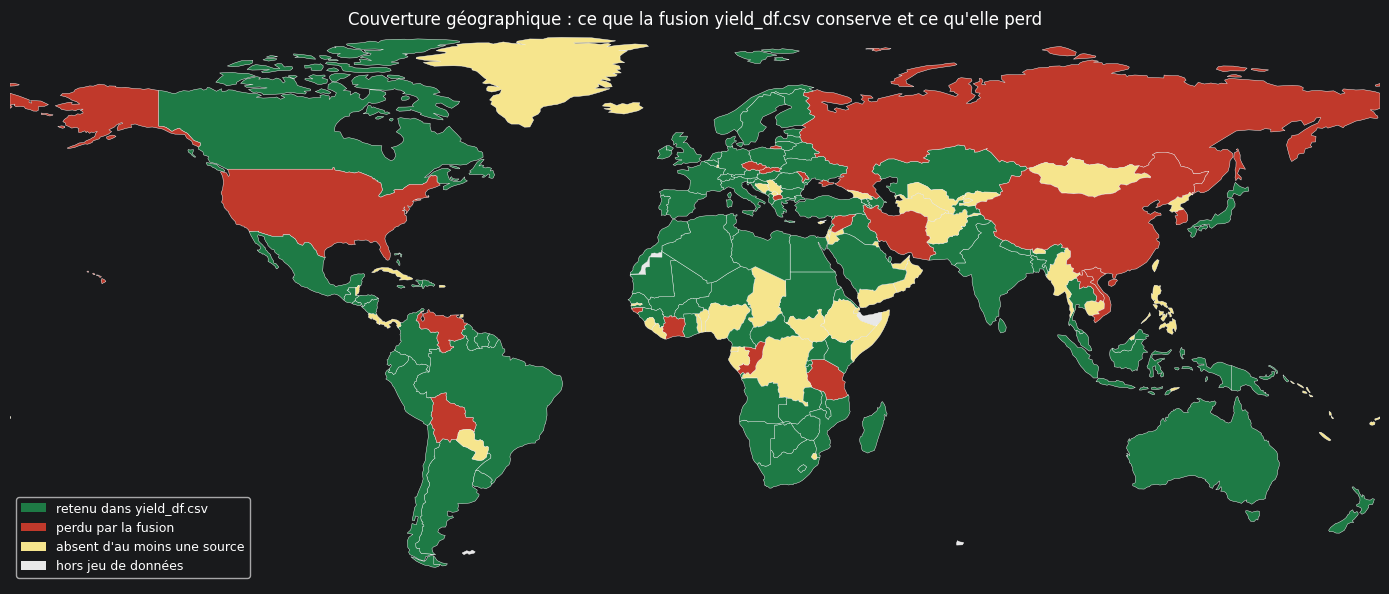

In [37]:
contours = geo.charger_contours()

categories = {}
for code in contours:
    if code in retenus:
        categories[code] = "retenu dans yield_df.csv"
    elif code in perdus:
        categories[code] = "perdu par la fusion"
    elif any(code in codes for codes in pays.values()):
        categories[code] = "absent d'au moins une source"

geo.plot_carte_categories(
    categories,
    couleurs={
        "retenu dans yield_df.csv": "#1e7a45",
        "perdu par la fusion": "#c0392b",
        "absent d'au moins une source": "#f6e58d",
    },
    titre="Couverture géographique : ce que la fusion yield_df.csv conserve et ce qu'elle perd",
    contours=contours,
)

**Observations :**

- `yield_df.csv` garde 99 pays, alors que 117 pays sont présents dans les quatre sources :
  18 pays sont perdus.
- Ces pertes viennent surtout de noms écrits différemment d'un fichier à l'autre
  (`United States of America` / `United States`, `Russian Federation` / `Russia`,
  `China, mainland` / `China`).
- Plusieurs grands producteurs sont concernés : États-Unis, Russie, Chine, Iran, Viêt Nam.
- Avec les doublons de température, c'est la deuxième raison de refaire l'assemblage au lieu
  d'utiliser `yield_df.csv`.

# Assemblage exploratoire

Les quatre sources sont assemblées avec une ligne par pays, année et culture, sur 1990-2013, pour
étudier leur évolution dans le temps.

Ce n'est pas le dataset final : l'assemblage contrôlé, le nettoyage et la sauvegarde de
`crop_yield_clean.csv` sont faits dans le notebook 04.

## Contrôles préalables

In [38]:
DEBUT, FIN = 1990, 2013

print("doublons sur la clé de chaque fichier")
print("  pesticides (Area, Year)      :", df_pesticides.duplicated(["Area", "Year"]).sum())
print("  rainfall   (Area, Year)      :", df_rainfall.duplicated(["Area", "Year"]).sum())
print("  yield      (Area, Item, Year):", df_yield.duplicated(["Area", "Item", "Year"]).sum())

print("\nplusieurs noms pointant vers un même code ISO3 :")
for nom, df, col in [("pesticides", df_pesticides, "Area"), ("rainfall", df_rainfall, "Area"),
                     ("temp", df_temp, "country"), ("yield", df_yield, "Area")]:
    codes = geo.vers_iso3(df[col].astype(str).unique())
    noms_par_code = {}
    for nom_pays, code_iso in codes.items():
        noms_par_code.setdefault(code_iso, []).append(nom_pays)
    collisions = {code: noms for code, noms in noms_par_code.items() if len(noms) > 1}
    print(f"  {nom:11} {collisions or 'aucune'}")

doublons sur la clé de chaque fichier
  pesticides (Area, Year)      : 0
  rainfall   (Area, Year)      : 0
  yield      (Area, Item, Year): 0

plusieurs noms pointant vers un même code ISO3 :
  pesticides  aucune
  rainfall    aucune
  temp        aucune
  yield       {'CHN': ['China', 'China, mainland']}


**Observations :**

- `pesticides.csv` et `rainfall.csv` ont une seule ligne par pays et par année ; `yield.csv` une
  seule par pays, culture et année.
- Un problème : `China` et `China, mainland` reçoivent le même code ISO3.

In [39]:
# China inclut Taïwan, Hong Kong et Macao ; China, mainland est la Chine continentale
chine = df_yield[df_yield["Area"].isin(["China", "China, mainland"])]
compare = chine.pivot_table(index=["Item", "Year"], columns="Area", values="Value")
ecart = (compare["China"] - compare["China, mainland"]).abs() / compare["China, mainland"]

print(f"couples (Item, Year) communs : {len(compare.dropna())}")
print(f"écart relatif moyen          : {ecart.mean():.2%}")

# Comment les autres sources nomment-elles la Chine ?
print("\nlibellés liés à la Chine, par source :")
for nom, df, colonne in [("yield.csv", df_yield, "Area"), ("rainfall.csv", df_rainfall, "Area"),
                         ("pesticides.csv", df_pesticides, "Area"), ("temp.csv", df_temp, "country")]:
    libelles = sorted(v for v in df[colonne].astype(str).unique()
                      if any(mot in v.lower() for mot in ["china", "hong kong", "macao", "taiwan"]))
    print(f"  {nom:16} {libelles}")

couples (Item, Year) communs : 448
écart relatif moyen          : 0.26%

libellés liés à la Chine, par source :
  yield.csv        ['China', 'China, Hong Kong SAR', 'China, Taiwan Province of', 'China, mainland']
  rainfall.csv     ['China', 'Hong Kong SAR, China', 'Macao SAR, China']
  pesticides.csv   ['China, Hong Kong SAR', 'China, Macao SAR', 'China, Taiwan Province of', 'China, mainland']
  temp.csv         ['China', 'Hong Kong', 'Taiwan']


**Observations :**

- Les deux séries de rendement sont presque identiques : 0,26 % d'écart moyen sur 448 couples
  culture-année.
- Les autres sources traitent Hong Kong, Macao et Taïwan à part, et `pesticides.csv` ne contient
  que `China, mainland`.
- On garde donc `China, mainland` et on écarte `China`.

## Préparation des sources

In [40]:
def ajoute_iso3(df, colonne_pays):
    """Ajoute une colonne iso3 à partir du nom de pays."""
    correspondances = geo.vers_iso3(df[colonne_pays].astype(str).unique())
    return df.assign(iso3=df[colonne_pays].map(correspondances))


# Rendement : une ligne par pays, année et culture
rendement = (
    df_yield[df_yield["Area"] != "China"]
    .query("@DEBUT <= Year <= @FIN")
    .pipe(ajoute_iso3, "Area")
    .rename(columns={"Area": "area", "Year": "year", "Item": "crop"})
    .assign(yield_t_ha=lambda d: d["Value"] / 10_000)   # hg/ha -> t/ha
    [["iso3", "area", "year", "crop", "yield_t_ha"]]
)

# Température : doublons exacts retirés, puis moyenne des relevés d'un pays et d'une année
temperature = (
    df_temp.drop_duplicates()
    .query("@DEBUT <= year <= @FIN")
    .pipe(ajoute_iso3, "country")
    .groupby(["iso3", "year"], as_index=False)["avg_temp"].mean()
)

# Pluie et pesticides : déjà une ligne par pays et par année
pluie = (
    df_rainfall.query("@DEBUT <= Year <= @FIN")
    .pipe(ajoute_iso3, "Area")
    .rename(columns={"Year": "year", "average_rain_fall_mm_per_year": "rain_mm"})
    [["iso3", "year", "rain_mm"]]
)

pesticides = (
    df_pesticides.query("@DEBUT <= Year <= @FIN")
    .pipe(ajoute_iso3, "Area")
    .rename(columns={"Year": "year", "Value": "pesticides_t"})
    [["iso3", "year", "pesticides_t"]]
)

La température d'un pays pour une année est la moyenne simple de ses relevés.

In [41]:
# Noms sans code ISO3 : on regarde ce qui sera écarté
for nom, prepare, colonne in [("rendement", rendement, "area"), ("température", temperature, None),
                              ("pluie", pluie, None), ("pesticides", pesticides, None)]:
    perdues = prepare["iso3"].isna().sum()
    print(f"{nom:12} {len(prepare):6} lignes | sans ISO3 : {perdues:5} ({perdues/len(prepare):.1%})")

noms_perdus = sorted(rendement.loc[rendement["iso3"].isna(), "area"].unique())
print(f"\npays du rendement sans code ISO3 ({len(noms_perdus)}) :")
print(", ".join(noms_perdus))

rendement     25848 lignes | sans ISO3 :  3169 (12.3%)
température    3192 lignes | sans ISO3 :     0 (0.0%)
pluie          4991 lignes | sans ISO3 :  1081 (21.7%)
pesticides     3860 lignes | sans ISO3 :   506 (13.1%)

pays du rendement sans code ISO3 (43) :
American Samoa, Antigua and Barbuda, Bahrain, Barbados, Belgium-Luxembourg, Bermuda, Cabo Verde, Cayman Islands, China, Hong Kong SAR, China, Taiwan Province of, Comoros, Cook Islands, Czechoslovakia, Dominica, Ethiopia PDR, Faroe Islands, French Guiana, French Polynesia, Grenada, Guadeloupe, Guam, Maldives, Malta, Martinique, Mauritius, Micronesia (Federated States of), Montserrat, Niue, Pacific Islands Trust Territory, Réunion, Saint Kitts and Nevis, Saint Lucia, Saint Vincent and the Grenadines, Samoa, Sao Tome and Principe, Serbia and Montenegro, Seychelles, Singapore, Sudan (former), Tonga, USSR, Wallis and Futuna Islands, Yugoslav SFR


**Observations :**

- Les noms sans code ISO3 sont des micro-États, des territoires ou des pays qui n'existent plus
  (URSS, Yougoslavie…).
- Ces lignes sont écartées de l'assemblage.

## Jointures

In [42]:
prefusion = rendement.dropna(subset=["iso3"])

for nom, source in [("pluie", pluie), ("température", temperature), ("pesticides", pesticides)]:
    avant = len(prefusion)
    prefusion = prefusion.merge(source.dropna(subset=["iso3"]), on=["iso3", "year"], how="left")
    print(f"+ {nom:12} {avant} -> {len(prefusion)} lignes")

cle_unique = not prefusion.duplicated(["iso3", "year", "crop"]).any()
print(f"\nlignes    : {len(prefusion)}")
print(f"pays      : {prefusion['iso3'].nunique()}")
print(f"cultures  : {prefusion['crop'].nunique()}")
print(f"années    : {prefusion['year'].min()} - {prefusion['year'].max()}")
print(f"clé (iso3, year, crop) unique : {cle_unique}")

assert cle_unique, "des lignes ont été dupliquées pendant les jointures"

+ pluie        22679 -> 22679 lignes
+ température  22679 -> 22679 lignes
+ pesticides   22679 -> 22679 lignes

lignes    : 22679
pays      : 168
cultures  : 10
années    : 1990 - 2013
clé (iso3, year, crop) unique : True


**Observations :**

- 22 679 lignes après les jointures, 168 pays, 10 cultures, 1990-2013.
- Une seule ligne par pays, année et culture : aucune ligne n'a été dupliquée.
- Les valeurs manquantes sont traitées dans le notebook 04.

## Effet de l'année

In [43]:
correlations = (
    prefusion.groupby("crop")
    .apply(lambda g: g["year"].corr(g["yield_t_ha"]), include_groups=False)
    .rename("corr_year_yield")
    .sort_values(ascending=False)
    .to_frame()
)
correlations.round(3)

,corr_year_yield
crop,
Cassava,0.180
Maize,0.155
Potatoes,0.153
"Rice, paddy",0.150
Wheat,0.121
Sorghum,0.106
Sweet potatoes,0.100
Soybeans,0.099
Yams,0.089


**Observations :**

- La corrélation entre l'année et le rendement est faible pour toutes les cultures : de 0,026
  (plantain) à 0,180 (manioc).
- Cette corrélation globale ne suffit pas à décrire les évolutions propres à chaque pays.

## Comparaison de périodes

In [44]:
periodes = prefusion.assign(
    periode=pd.cut(prefusion["year"], [1989, 1999, 2009, 2013],
                   labels=["1990-1999", "2000-2009", "2010-2013"])
)

par_periode = periodes.pivot_table(index="crop", columns="periode", values="yield_t_ha",
                                   aggfunc="mean", observed=True)
par_periode["évolution (%)"] = (
    (par_periode["2010-2013"] / par_periode["1990-1999"] - 1) * 100
).round(1)

par_periode.round(2).sort_values("évolution (%)", ascending=False)

periode,1990-1999,2000-2009,2010-2013,évolution (%)
crop,,,,
Maize,3.10,3.93,4.56,47.2
Sorghum,1.69,1.98,2.26,33.6
Cassava,8.81,10.20,11.26,27.8
Potatoes,15.53,17.86,19.33,24.5
"Rice, paddy",3.15,3.50,3.91,24.0
Wheat,2.55,2.88,3.14,22.9
Sweet potatoes,8.66,9.54,10.58,22.1
Soybeans,1.46,1.54,1.65,12.9
Yams,8.62,9.32,9.57,11.1


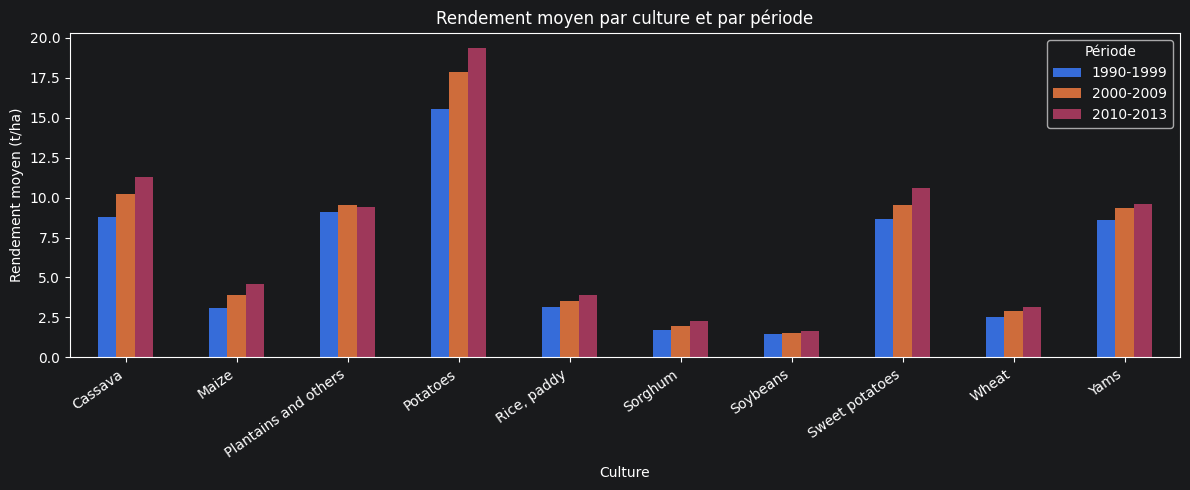

In [45]:
ax = par_periode.drop(columns="évolution (%)").plot(kind="bar", figsize=(12, 5))
ax.set_xlabel("Culture")
ax.set_ylabel("Rendement moyen (t/ha)")
ax.set_title("Rendement moyen par culture et par période")
ax.legend(title="Période")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**Observations :**

- Toutes les cultures progressent entre 1990-1999 et 2010-2013 : de +3,8 % (plantain) à +47,2 %
  (maïs).
- Les rendements des années 1990 sont nettement plus bas que ceux des dernières années.

## Stabilité de la pluie dans le temps

In [46]:
# La pluie varie-t-elle d'une année sur l'autre pour un même pays ?
valeurs_par_pays = prefusion.groupby("iso3")["rain_mm"].nunique(dropna=True)
avec_valeur = valeurs_par_pays[valeurs_par_pays > 0]
print(f"pays ayant une valeur de pluie : {len(avec_valeur)} / {prefusion['iso3'].nunique()}")
print(f"dont une seule valeur sur les 24 ans : {(avec_valeur == 1).sum()}")

pays ayant une valeur de pluie : 167 / 168
dont une seule valeur sur les 24 ans : 167


**Observations :**

- Parmi les pays renseignés, `rain_mm` est fixe : aucune variation annuelle n'est observée.

## Effet du changement de pays

On compare les tendances avec tous les pays puis à pays constants.
Pour la température, chaque pays renseigné compte une seule fois par année.

pays par année : 138 en 1990 -> 168 en 2013
pays présents chaque année : 138 sur 168
pays avec température chaque année : 108


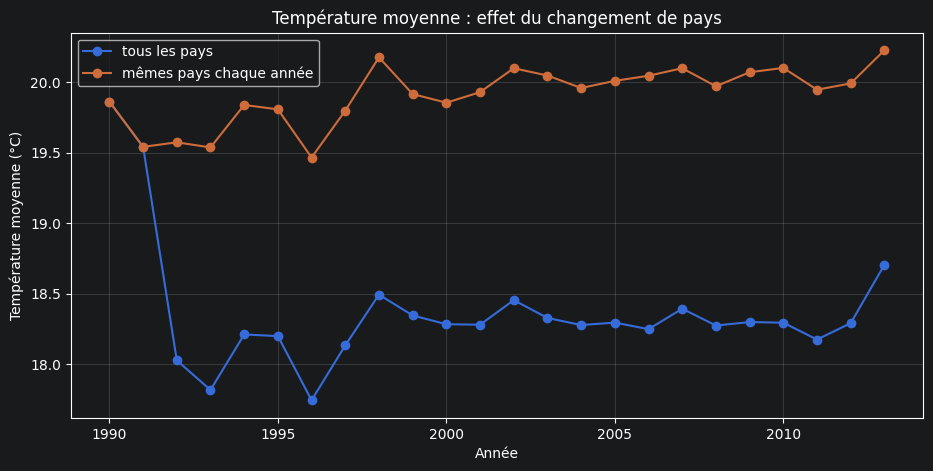

tous les pays            1990 -> 2013 : -1.16 °C
mêmes pays chaque année  1990 -> 2013 : +0.36 °C


In [47]:
pays_par_an = prefusion.groupby("year")["iso3"].nunique()
print(f"pays par année : {pays_par_an[1990]} en 1990 -> {pays_par_an[2013]} en 2013")

# Pays présents toutes les années de 1990 à 2013
stables = (
    prefusion.groupby("iso3")["year"].nunique()
    .pipe(lambda s: s[s == prefusion["year"].nunique()].index)
)
memes_pays = prefusion[prefusion["iso3"].isin(stables)]
print(f"pays présents chaque année : {len(stables)} sur {prefusion['iso3'].nunique()}")

temperature_pays = prefusion[["iso3", "year", "avg_temp"]].drop_duplicates(["iso3", "year"])
temperature_pays = temperature_pays.dropna(subset=["avg_temp"])
nb_annees = prefusion["year"].nunique()
couverture_temperature = temperature_pays.groupby("iso3")["year"].nunique()
pays_temperature = couverture_temperature[couverture_temperature == nb_annees].index
temperature_stable = temperature_pays[temperature_pays["iso3"].isin(pays_temperature)]
print(f"pays avec température chaque année : {len(pays_temperature)}")

comparaison = pd.DataFrame({
    "tous les pays": temperature_pays.groupby("year")["avg_temp"].mean(),
    "mêmes pays chaque année": temperature_stable.groupby("year")["avg_temp"].mean(),
})

ax = comparaison.plot(figsize=(11, 5), marker="o")
ax.set_xlabel("Année")
ax.set_ylabel("Température moyenne (°C)")
ax.set_title("Température moyenne : effet du changement de pays")
ax.grid(alpha=0.3)
plt.show()

for colonne in comparaison:
    ecart = comparaison[colonne].loc[2013] - comparaison[colonne].loc[1990]
    print(f"{colonne:24} 1990 -> 2013 : {ecart:+.2f} °C")

In [48]:
# Le nombre de pays déclarants par culture est-il stable ?
prefusion.pivot_table(index="year", columns="crop", values="iso3", aggfunc="nunique").loc[[1990, 1992, 2000, 2013]]

crop,Cassava,Maize,Plantains and others,Potatoes,"Rice, paddy",Sorghum,Soybeans,Sweet potatoes,Wheat,Yams
year,,,,,,,,,,
1990,75,122,39,113,102,87,72,84,94,38
1992,75,141,41,132,111,96,83,84,113,40
2000,75,147,41,141,111,101,87,90,120,42
2013,76,152,42,145,112,106,92,92,122,44


In [49]:
# Les hausses de rendement se retrouvent-elles avec les mêmes pays chaque année ?
rendements_renseignes = prefusion.dropna(subset=["yield_t_ha"])
couverture_cultures = rendements_renseignes.groupby(["iso3", "crop"])["year"].transform("nunique")
rendements_stables = rendements_renseignes[couverture_cultures == prefusion["year"].nunique()]
print("Pays présents chaque année, par culture :")
print(rendements_stables.groupby("crop")["iso3"].nunique())

periodes_memes_pays = rendements_stables.assign(
    periode=pd.cut(rendements_stables["year"], [1989, 1999, 2009, 2013],
                   labels=["1990-1999", "2000-2009", "2010-2013"])
)
evolution_memes_pays = periodes_memes_pays.pivot_table(index="crop", columns="periode", values="yield_t_ha",
                                                       aggfunc="mean", observed=True)

pd.DataFrame({
    "tous les pays (%)": par_periode["évolution (%)"],
    "mêmes pays chaque année (%)": (
        (evolution_memes_pays["2010-2013"] / evolution_memes_pays["1990-1999"] - 1) * 100
    ).round(1),
}).sort_values("tous les pays (%)", ascending=False)

Pays présents chaque année, par culture :
crop
Cassava                  75
Maize                   122
Plantains and others     39
Potatoes                113
Rice, paddy             100
Sorghum                  82
Soybeans                 69
Sweet potatoes           84
Wheat                    91
Yams                     38
Name: iso3, dtype: int64


,tous les pays (%),mêmes pays chaque année (%)
crop,,
Maize,47.2,41.7
Sorghum,33.6,18.6
Cassava,27.8,28.5
Potatoes,24.5,23.1
"Rice, paddy",24.0,23.6
Wheat,22.9,18.7
Sweet potatoes,22.1,19.9
Soybeans,12.9,11.2
Yams,11.1,10.6


**Observations :**

- Le nombre de pays passe de 138 en 1990 à 168 en 2013, avec un saut en 1992.
- La température est comparée sur les pays ayant une valeur chaque année, sans pondération par le nombre de cultures.
- Pour les rendements, les pays constants sont sélectionnés séparément pour chaque culture.

# Conclusion

- Période commune aux quatre sources : 1990-2013.
- Points à traiter à l'assemblage : plusieurs températures par pays et par année, noms de pays
  écrits différemment, doublon `China` / `China, mainland`.
- La pluie est une valeur fixe par pays, et l'année 2003 manque dans `rainfall.csv`.
- Les cultures ont des niveaux de rendement très différents, ce qui manque au dataset parcellaire.